In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("/content/adult.csv")

In [4]:
df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.shape

(48842, 15)

In [6]:
k=np.sum(df.duplicated())
k

np.int64(52)

In [7]:
df=df.drop_duplicates()


In [8]:
df.shape

(48790, 15)

In [9]:
df.isnull().mean()*100



,0
age,0.0
workclass,0.0
fnlwgt,0.0
education,0.0
educational-num,0.0
marital-status,0.0
occupation,0.0
relationship,0.0
race,0.0
gender,0.0


In [43]:
df = df.replace("?", np.nan)
df = df.apply(lambda col: col.fillna(col.mode()[0]))


In [44]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [45]:
x=df.drop("income",axis=1)
y=df["income"]

In [46]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
lb=LabelEncoder()
y=lb.fit_transform(y)



In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
trf1=ColumnTransformer([
       ("one_hot",OneHotEncoder(sparse_output=False,drop="first",handle_unknown="ignore"),[1,3,5,6,7,8,9,13]),
       ("scaling",StandardScaler(),[2,10,11])],remainder="passthrough")

In [53]:
scores=[]

for i in range(1,20):
  pipe=make_pipeline(trf1,KNeighborsClassifier(n_neighbors=i))
  pipe.fit(x_train,y_train)
  l=np.mean(cross_val_score(pipe,x_train,y_train,cv=5,scoring="accuracy"))
  scores.append(l)


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

In [54]:
scores

[np.float64(0.7760552991181272),
 np.float64(0.8008556016774266),
 np.float64(0.801111739364487),
 np.float64(0.8085671651812898),
 np.float64(0.8108216901070374),
 np.float64(0.8151771728670287),
 np.float64(0.8137937497442216),
 np.float64(0.8172011420405838),
 np.float64(0.8168168386957433),
 np.float64(0.8198912818636618),
 np.float64(0.8195069621096265),
 np.float64(0.8205061672154066),
 np.float64(0.8196094309681744),
 np.float64(0.8210186001177984),
 np.float64(0.8213260427936706),
 np.float64(0.8218896691023492),
 np.float64(0.8219408756359916),
 np.float64(0.822504524917543),
 np.float64(0.8223508232706408)]

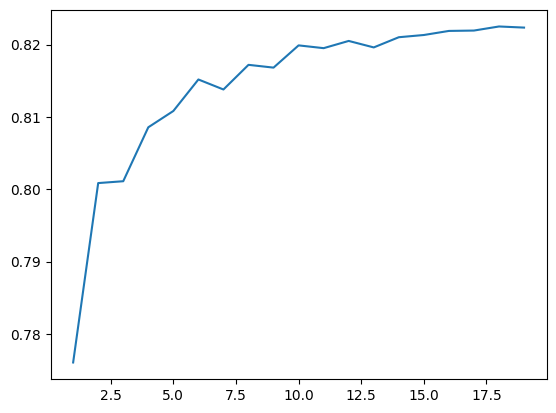

In [55]:
plt.plot(range(1,20),scores)
plt.show()

ValueError: n_features must be equal to 2. Got 14 instead.